# 🚀 Batalha de Feature Engineering (Séries Temporais)
**Manual Feature Engineering vs Automated Feature Engineering (`tsfresh`)**

Neste experimento, exploraremos o impacto da extração de features no desempenho de modelos baseados em árvores (LightGBM e Random Forest) utilizando o clássico dataset *Daily Minimum Temperatures*.

Compararemos duas abordagens:
1. **Engenharia Manual:** Criação cirúrgica e intuitiva de *Lags*, *Rolling Windows* e *Sazonais*.
2. **Engenharia Automática:** Força bruta matemática utilizando `tsfresh` para extrair centenas de características estatísticas (Fourier, Entropy, Autocorrelation, etc.) e filtrá-las.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import roll_time_series, impute
from tsfresh.feature_extraction import EfficientFCParameters, MinimalFCParameters

plt.style.use('dark_background')



## 1. Carregamento do Dataset (Daily Minimum Temperatures)


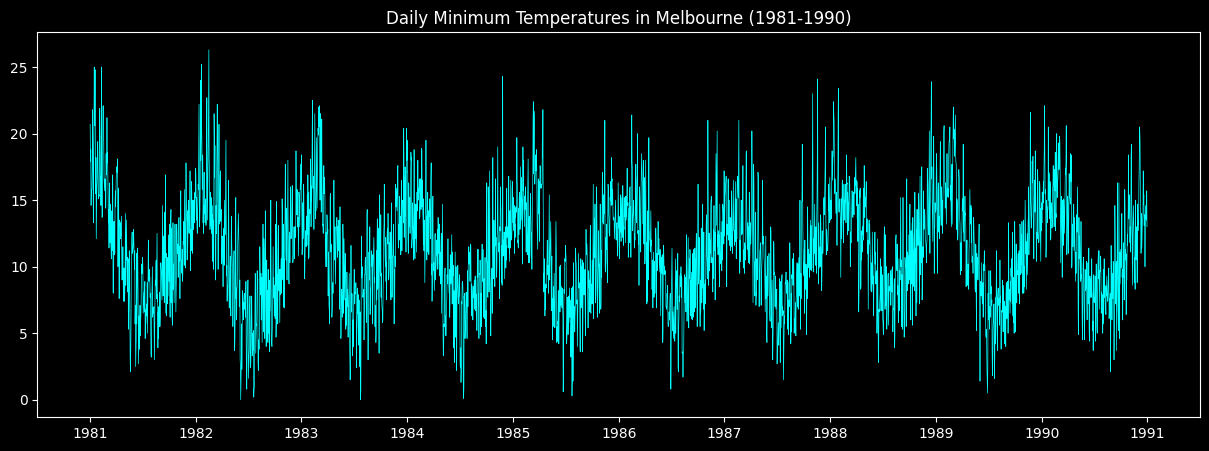

Total de amostras: 3650


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_raw = pd.read_csv(url, parse_dates=['Date'])
df_raw = df_raw.rename(columns={'Date': 'date', 'Temp': 'temperature'})
df_raw = df_raw.sort_values('date').reset_index(drop=True)

plt.figure(figsize=(15, 5))
plt.plot(df_raw['date'], df_raw['temperature'], color='cyan', linewidth=0.5)
plt.title('Daily Minimum Temperatures in Melbourne (1981-1990)')
plt.show()

print(f"Total de amostras: {len(df_raw)}")



## 2. Abordagem 1: Feature Engineering Manual 🧠
Construiremos defasagens (lags), médias móveis e atributos temporais de forma explícita.


In [3]:
df_manual = df_raw.copy()
start_time = time.time()

# Target (Prever o dia seguinte)
# Queremos prever o t, usando as features disponíveis até t-1.
# Portanto, a temperatura do próprio dia 't' é o target. 
# As features serão os lags t-1, t-2, etc.

df_manual['target'] = df_manual['temperature']

# Lags
for i in [1, 2, 3, 7, 30, 365]:
    df_manual[f'lag_{i}'] = df_manual['temperature'].shift(i)

# Rolling Windows (baseadas no lag 1 para não vazar o target)
df_manual['rolling_mean_7'] = df_manual['lag_1'].rolling(window=7).mean()
df_manual['rolling_std_7'] = df_manual['lag_1'].rolling(window=7).std()
df_manual['rolling_mean_30'] = df_manual['lag_1'].rolling(window=30).mean()
df_manual['rolling_std_30'] = df_manual['lag_1'].rolling(window=30).std()

# Date Features
df_manual['month'] = df_manual['date'].dt.month
df_manual['day_of_week'] = df_manual['date'].dt.dayofweek
df_manual['day_of_year'] = df_manual['date'].dt.dayofyear
df_manual['is_weekend'] = df_manual['day_of_week'].isin([5, 6]).astype(int)

df_manual = df_manual.dropna().reset_index(drop=True)
manual_fe_time = time.time() - start_time

print(f"Feature Engineering Manual concluída em {manual_fe_time:.2f} segundos.")
print(f"Shape final: {df_manual.shape}")



Feature Engineering Manual concluída em 0.00 segundos.
Shape final: (3285, 17)


In [4]:
# Split Train/Test (Últimos 365 dias para teste)
test_size = 365
train_manual = df_manual.iloc[:-test_size]
test_manual = df_manual.iloc[-test_size:]

X_train_m = train_manual.drop(columns=['date', 'temperature', 'target'])
y_train_m = train_manual['target']
X_test_m = test_manual.drop(columns=['date', 'temperature', 'target'])
y_test_m = test_manual['target']

results = []

def evaluate(model_name, fe_type, y_true, y_pred, train_time, fe_time, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append({
        'Model': model_name,
        'FE': fe_type,
        'N_Features': n_features,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'FE_Time(s)': fe_time,
        'Train_Time(s)': train_time
    })
    print(f"[{fe_type}] {model_name} | MAE: {mae:.4f} | R2: {r2:.4f}")

# Train LightGBM Manual
start = time.time()
lgb_m = LGBMRegressor(random_state=42, n_estimators=100)
lgb_m.fit(X_train_m, y_train_m)
t_time = time.time() - start
evaluate('LightGBM', 'Manual', y_test_m, lgb_m.predict(X_test_m), t_time, manual_fe_time, X_train_m.shape[1])

# Train RF Manual
start = time.time()
rf_m = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
rf_m.fit(X_train_m, y_train_m)
t_time = time.time() - start
evaluate('RandomForest', 'Manual', y_test_m, rf_m.predict(X_test_m), t_time, manual_fe_time, X_train_m.shape[1])



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2442
[LightGBM] [Info] Number of data points in the train set: 2920, number of used features: 14
[LightGBM] [Info] Start training from score 11.073836


[Manual] LightGBM | MAE: 1.8206 | R2: 0.6452


[Manual] RandomForest | MAE: 1.7630 | R2: 0.6631


## 3. Abordagem 2: Feature Engineering Automática (`tsfresh`) 🤖
Utilizaremos `tsfresh` para extrair centenas de características temporais da série de forma automática.
Para evitar vazamento temporal, usaremos `roll_time_series` para criar janelas deslizantes (usaremos max_timeshift de 30 dias para emular os lags curtos, sem o lag de 365 para manter a rapidez, ou usaremos o EfficientFCParameters).


In [5]:
start_time = time.time()

df_tsfresh = df_raw[['date', 'temperature']].copy()
df_tsfresh['id'] = 1 # Série única univariada

# O tsfresh exige um formato específico. Com roll_time_series, criamos sub-dataframes para cada passo de tempo.
# max_timeshift=30 significa que cada janela vai olhar no máximo 30 dias para trás (lag máximo 30).
df_rolled = roll_time_series(df_tsfresh, column_id="id", column_sort="date", 
                             max_timeshift=30, min_timeshift=5)

print(f"Dataframe enrolado (rolled) criado. Shape: {df_rolled.shape}")

# Agora, vamos remover o registro t da janela, pois a janela inclui o tempo t, e queremos prever t usando < t.
# Felizmente, em ML de séries temporais com tsfresh, a feature extraída no tempo T representa o passado (incluindo T).
# Para prever T+1, faremos um shift no target.

# Extração de features
X_auto = extract_features(df_rolled, column_id="id", column_sort="date", 
                          default_fc_parameters=EfficientFCParameters(), 
                          impute_function=None, n_jobs=4)

# O X_auto tem um MultiIndex (id, date). 
X_auto = X_auto.reset_index(level=0, drop=True) # Manter apenas a data no index
X_auto = X_auto.sort_index()

# O X_auto no tempo t contém features processadas de [t-30 até t].
# Portanto, essas features podem ser usadas para prever a temperatura no tempo t+1.
target = df_raw.set_index('date')['temperature'].shift(-1) # t+1

# Juntamos
df_auto_full = X_auto.join(target.rename('target'), how='inner').dropna(subset=['target'])

# Imputar Nans nas features (tsfresh tem função pra isso, mas faremos simples)
impute(df_auto_full)

# Separar X e y
y_auto_full = df_auto_full['target']
X_auto_full = df_auto_full.drop(columns=['target'])

# Filtragem Inteligente (Feature Selection) pelo tsfresh
X_auto_selected = select_features(X_auto_full, y_auto_full)

import re
X_auto_selected.columns = [re.sub(r'[",\[\]{}:]', '', str(col)) for col in X_auto_selected.columns]

auto_fe_time = time.time() - start_time

print(f"Feature Engineering Automática concluída em {auto_fe_time:.2f} segundos.")
print(f"Features originais: {X_auto_full.shape[1]} | Features selecionadas: {X_auto_selected.shape[1]}")



Rolling:   0%|          | 0/80 [00:00<?, ?it/s]

Rolling:   1%|▏         | 1/80 [00:01<02:02,  1.55s/it]

Rolling:   5%|▌         | 4/80 [00:01<00:24,  3.11it/s]

Rolling:  14%|█▍        | 11/80 [00:01<00:07,  9.79it/s]

Rolling:  26%|██▋       | 21/80 [00:01<00:02, 21.23it/s]

...

Feature Extraction:  85%|████████▌ | 17/20 [00:19<00:03,  1.21s/it]

Feature Extraction:  90%|█████████ | 18/20 [00:19<00:01,  1.06it/s]

Feature Extraction: 100%|██████████| 20/20 [00:20<00:00,  1.76it/s]

Feature Extraction: 100%|██████████| 20/20 [00:20<00:00,  1.01s/it]

Feature Engineering Automática concluída em 28.51 segundos.
Features originais: 777 | Features selecionadas: 267


In [6]:
# Split Train/Test
train_auto_x = X_auto_selected.iloc[:-test_size]
train_auto_y = y_auto_full.iloc[:-test_size]
test_auto_x = X_auto_selected.iloc[-test_size:]
test_auto_y = y_auto_full.iloc[-test_size:]

# Train LightGBM Auto
start = time.time()
lgb_a = LGBMRegressor(random_state=42, n_estimators=100)
lgb_a.fit(train_auto_x, train_auto_y)
t_time = time.time() - start
evaluate('LightGBM', 'Automated (tsfresh)', test_auto_y, lgb_a.predict(test_auto_x), t_time, auto_fe_time, train_auto_x.shape[1])

# Train RF Auto
start = time.time()
rf_a = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
rf_a.fit(train_auto_x, train_auto_y)
t_time = time.time() - start
evaluate('RandomForest', 'Automated (tsfresh)', test_auto_y, rf_a.predict(test_auto_x), t_time, auto_fe_time, train_auto_x.shape[1])



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 56164
[LightGBM] [Info] Number of data points in the train set: 3279, number of used features: 267
[LightGBM] [Info] Start training from score 11.111863


[Automated (tsfresh)] LightGBM | MAE: 1.8151 | R2: 0.6310


[Automated (tsfresh)] RandomForest | MAE: 1.7921 | R2: 0.6286


## 4. Batalha Final: Manual vs Automático ⚔️


,Model,FE,N_Features,MAE,RMSE,R2,FE_Time(s),Train_Time(s)
1,RandomForest,Manual,14,1.763008,2.238290,0.663109,0.004998,0.481538
3,RandomForest,Automated (tsfresh),267,1.792110,2.350137,0.628599,28.509273,10.493330
2,LightGBM,Automated (tsfresh),267,1.815069,2.342500,0.631009,28.509273,0.329685
0,LightGBM,Manual,14,1.820604,2.297104,0.645172,0.004998,0.245839


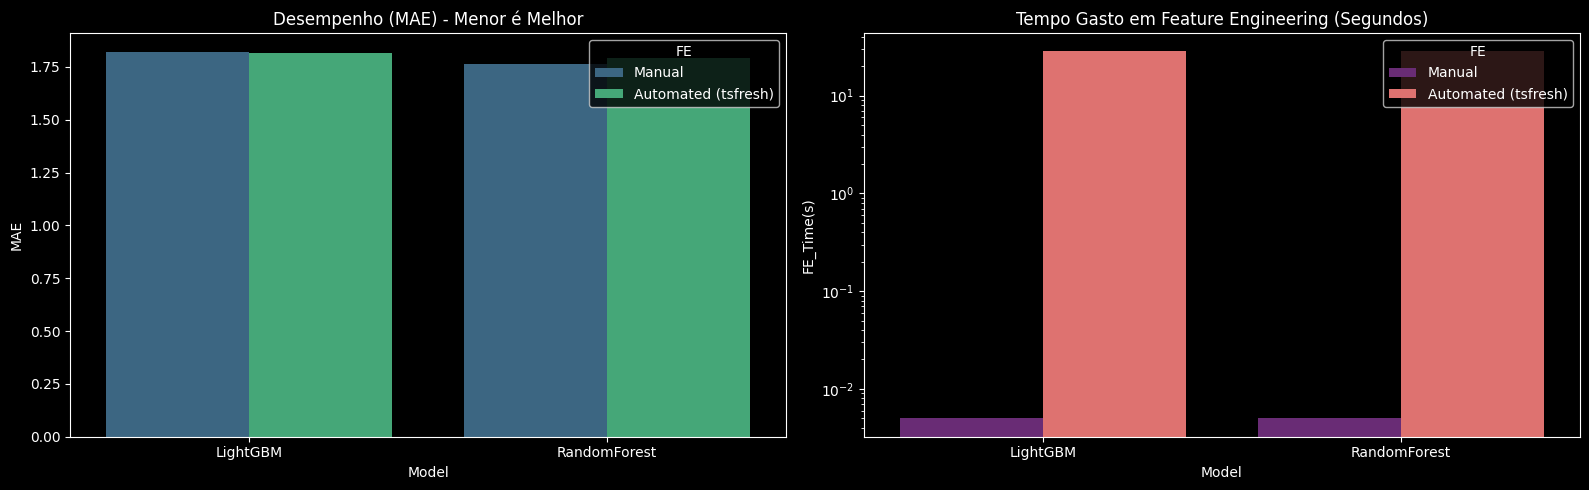

In [7]:
res_df = pd.DataFrame(results)
display(res_df.sort_values('MAE'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=res_df, x='Model', y='MAE', hue='FE', ax=axes[0], palette='viridis')
axes[0].set_title('Desempenho (MAE) - Menor é Melhor')

sns.barplot(data=res_df, x='Model', y='FE_Time(s)', hue='FE', ax=axes[1], palette='magma')
axes[1].set_title('Tempo Gasto em Feature Engineering (Segundos)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

